## Part 1: The Core Simulation Engine

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Base Parameters from Avellaneda-Stoikov (2006)
s_0 = 100.0       
T = 1.0           
sigma = 2.0       
dt = 0.005        
k = 1.5           
A = 140.0         
simulations = 1000 
N = int(T / dt)   
time_grid = np.linspace(0, T, N)

def simulate_market_maker(strategy="inventory", ask_multiplier=1.0, bid_multiplier=1.0, jump_diffusion=False, gamma=0.1):
    S = np.zeros(N)
    S[0] = s_0
    q = np.zeros(N)  
    X = np.zeros(N)  
    
    # Tracking arrays for Graph 1
    r_track = np.zeros(N)
    p_a_track = np.zeros(N)
    p_b_track = np.zeros(N)
    
    for i in range(N - 1):
        t = time_grid[i]
        
        r = S[i] - q[i] * gamma * (sigma ** 2) * (T - t) 
        optimal_spread = gamma * (sigma ** 2) * (T - t) + (2 / gamma) * np.log(1 + gamma / k)
        
        if strategy == "inventory":
            p_a = r + optimal_spread / 2
            p_b = r - optimal_spread / 2
        else: 
            p_a = S[i] + optimal_spread / 2
            p_b = S[i] - optimal_spread / 2
            
        r_track[i] = r
        p_a_track[i] = p_a
        p_b_track[i] = p_b
        
        delta_a = p_a - S[i]
        delta_b = S[i] - p_b
        
        lambda_a = A * np.exp(-k * delta_a) * ask_multiplier
        lambda_b = A * np.exp(-k * delta_b) * bid_multiplier
        
        if np.random.rand() < (lambda_a * dt):
            q[i+1] = q[i] - 1
            X[i+1] = X[i] + p_a
        else:
            q[i+1] = q[i]
            X[i+1] = X[i]
            
        if np.random.rand() < (lambda_b * dt):
            q[i+1] = q[i+1] + 1
            X[i+1] = X[i+1] - p_b
            
        price_shock = np.random.choice([1, -1]) * sigma * np.sqrt(dt) 
        if jump_diffusion and np.random.rand() < (5 * dt): 
            price_shock += np.random.choice([1, -1]) * np.random.exponential(1.5)
            
        S[i+1] = S[i] + price_shock
        
    # Carry forward final step for trackers
    r_track[-1], p_a_track[-1], p_b_track[-1] = r_track[-2], p_a_track[-2], p_b_track[-2]
    PnL = X + q * S
    
    return time_grid, S, q, X, PnL, r_track, p_a_track, p_b_track

## Part 2: Running the Monte Carlo & Generating Visualizations
This block runs both strategies 1,000 times, computes the performance metrics required (Profit, Std Dev, Final $q$), and generates the visualizations.

Running simulations, please wait...


--- Performance Metrics ---
 Strategy  Mean Profit  Std Dev (Profit)  Mean Final q  Std Dev (Final q)  Sharpe Ratio
Inventory        64.59              6.75         -0.07               2.99          9.56
Symmetric        67.42             12.88         -0.19               8.34          5.23


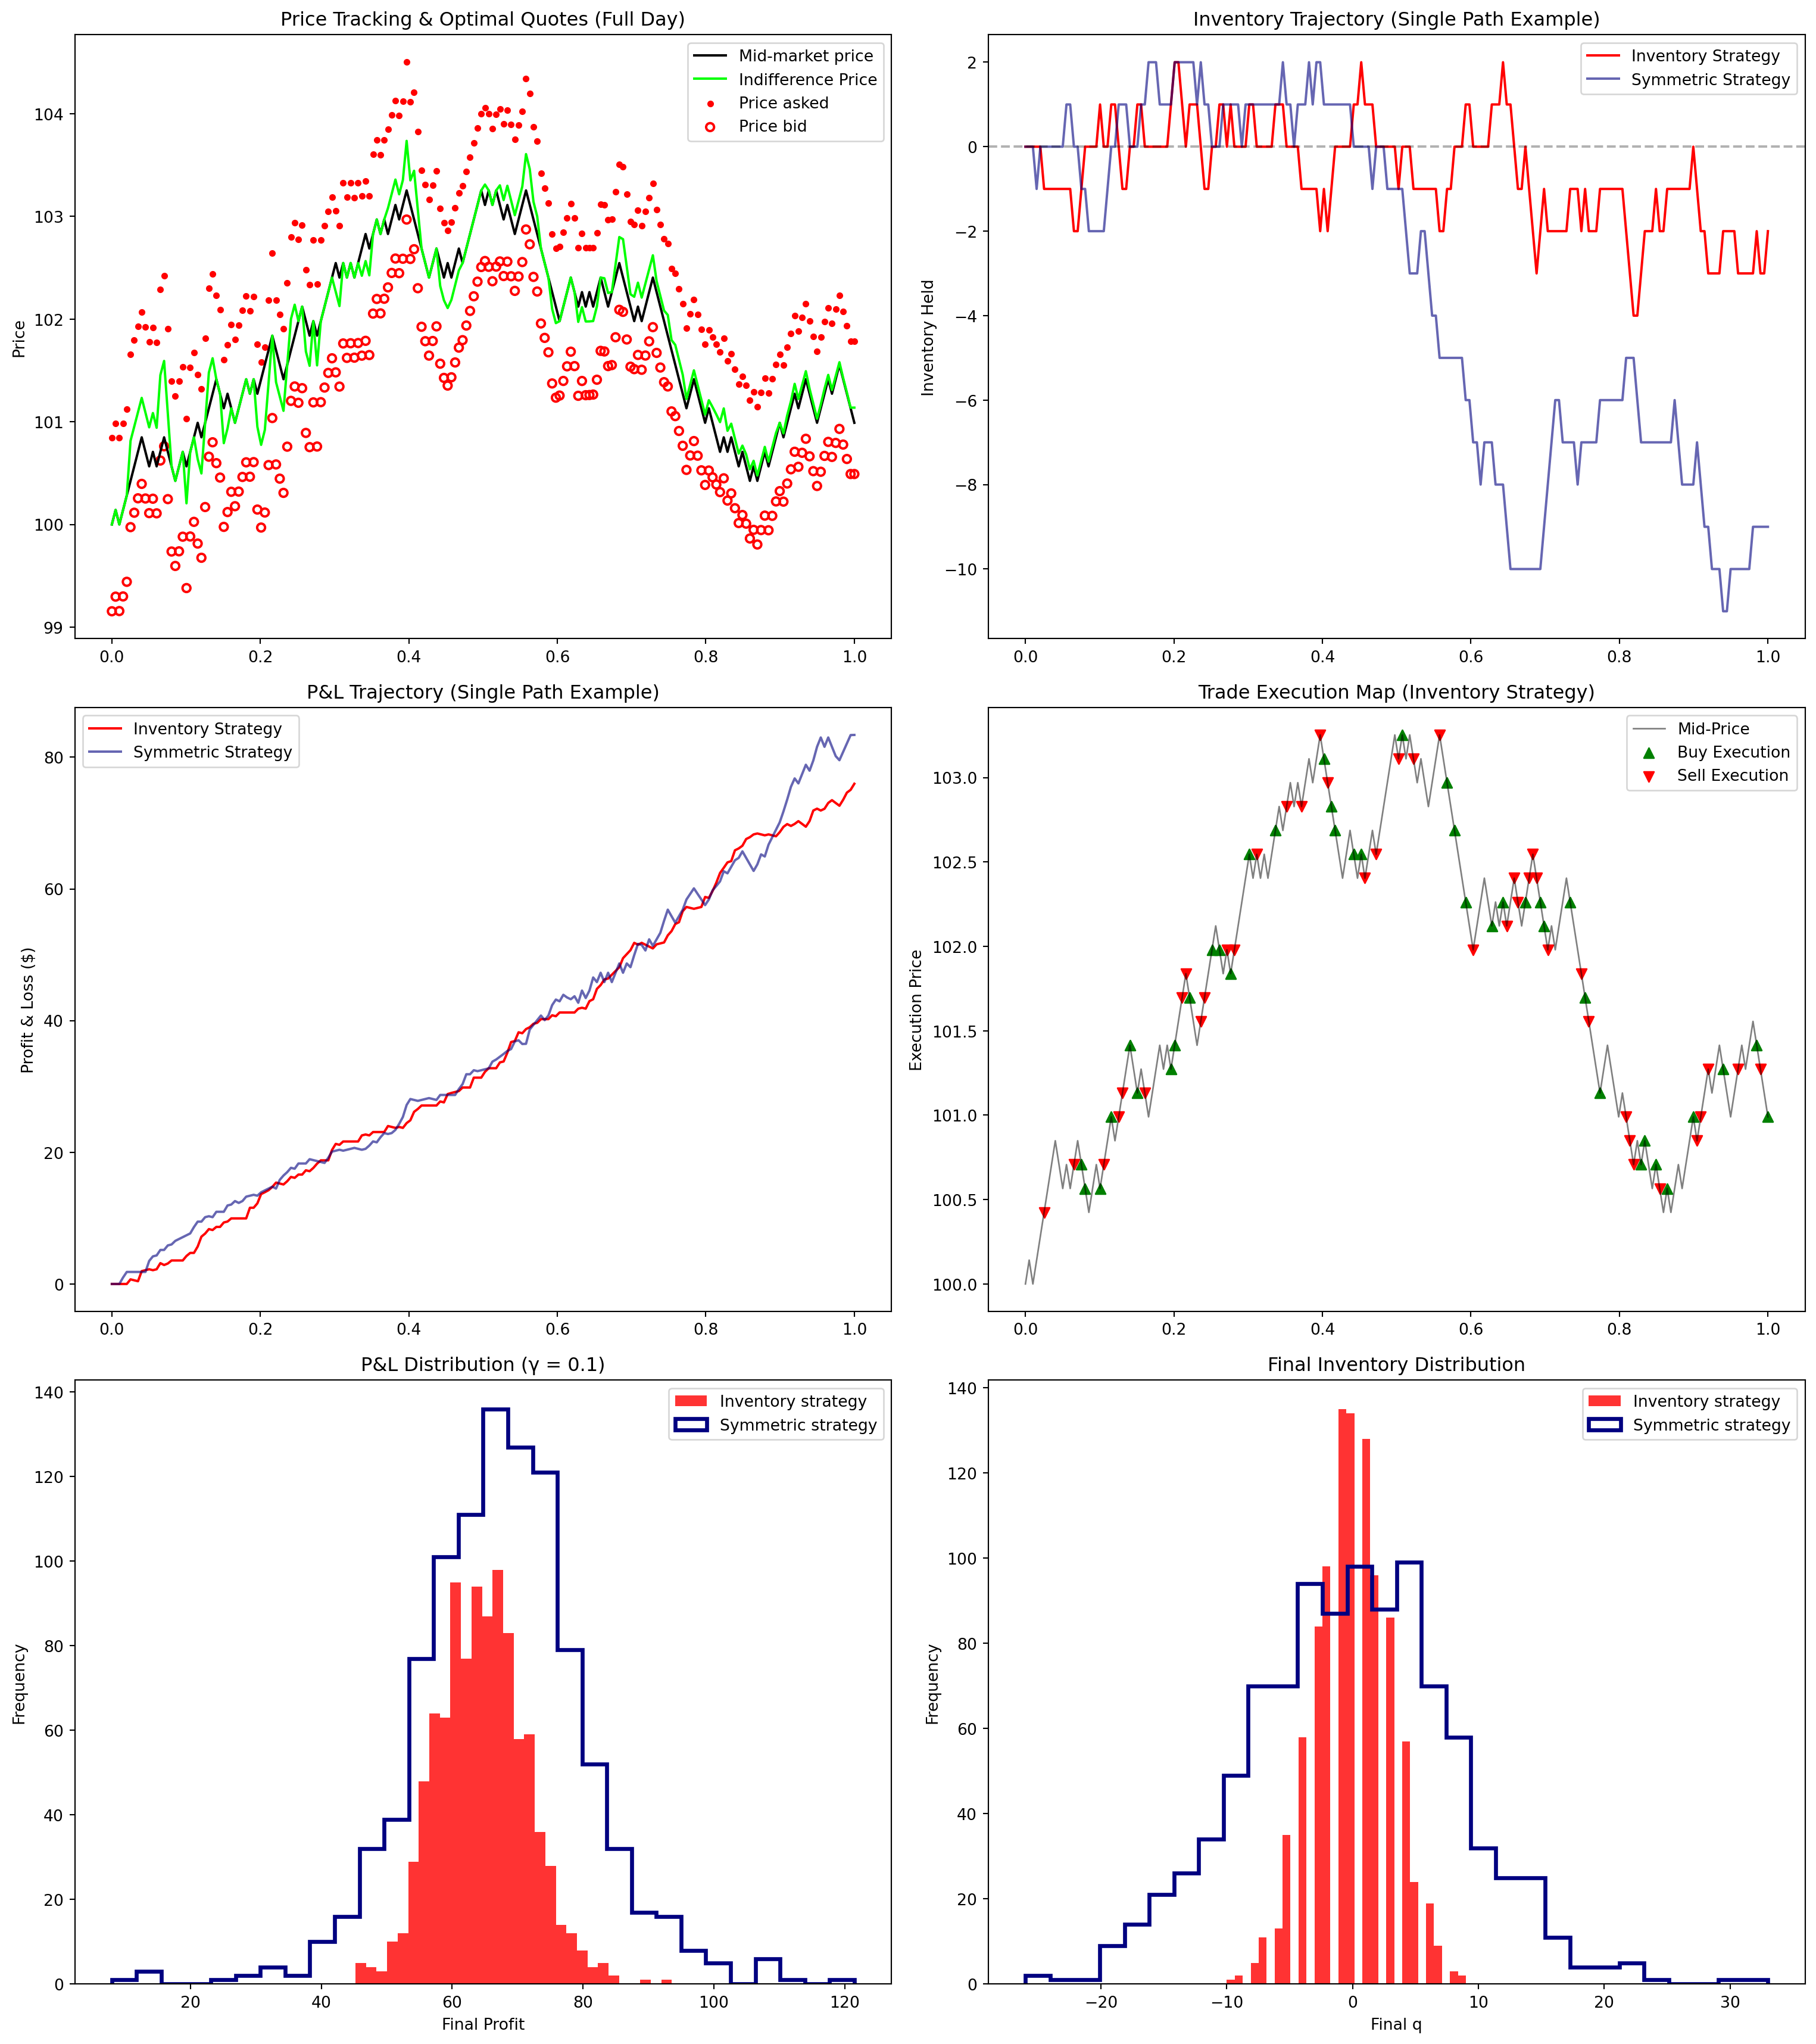

In [2]:
def run_monte_carlo(ask_mult=1.0, bid_mult=1.0, jumps=False, gamma_val=0.1):
    results = {"inventory": {"pnl": [], "final_q": []}, 
               "symmetric": {"pnl": [], "final_q": []}}
    
    sample_paths = {}
    
    print("Running simulations, please wait...")
    for strat in ["inventory", "symmetric"]:
        for i in range(simulations):
            t, S, q, X, PnL, r_t, p_a_t, p_b_t = simulate_market_maker(
                strategy=strat, ask_multiplier=ask_mult, bid_multiplier=bid_mult, jump_diffusion=jumps, gamma=gamma_val
            )
            results[strat]["pnl"].append(PnL[-1])
            results[strat]["final_q"].append(q[-1])
            
            if i == 0:
                sample_paths[strat] = (t, S, q, PnL, r_t, p_a_t, p_b_t)
                
    # Calculate Risk Metrics
    metrics = []
    for strat in ["inventory", "symmetric"]:
        pnl_array = np.array(results[strat]["pnl"])
        q_array = np.array(results[strat]["final_q"])
        
        metrics.append({
            "Strategy": strat.capitalize(),
            "Mean Profit": np.round(np.mean(pnl_array), 2),
            "Std Dev (Profit)": np.round(np.std(pnl_array), 2),
            "Mean Final q": np.round(np.mean(q_array), 2),
            "Std Dev (Final q)": np.round(np.std(q_array), 2),
            "Sharpe Ratio": np.round(np.mean(pnl_array) / np.std(pnl_array), 2) if np.std(pnl_array) > 0 else 0
        })
        
    df_metrics = pd.DataFrame(metrics)
    print("--- Performance Metrics ---")
    print(df_metrics.to_string(index=False))
    
    # --- Visualizations (6-Panel Layout) ---
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    
    t, S, q, PnL, r_t, p_a_t, p_b_t = sample_paths["inventory"]
    
# 1. Price Tracking (Full Day)
    axs[0, 0].plot(t, S, label='Mid-market price', color='black', linewidth=1.5)
    axs[0, 0].plot(t, r_t, label='Indifference Price', color='lime', linewidth=1.5)
    
    # Solid red dots for the Ask
    axs[0, 0].scatter(t, p_a_t, color='red', s=10, label='Price asked') 
    
    # Larger hollow red donuts for the Bid
    axs[0, 0].scatter(t, p_b_t, facecolors='none', edgecolors='red', linewidths=1.5, s=25, label='Price bid') 
    
    axs[0, 0].set_title("Price Tracking & Optimal Quotes (Full Day)")
    axs[0, 0].set_ylabel("Price")
    axs[0, 0].legend()

    # 2. Inventory Trajectory
    axs[0, 1].plot(t, q, label="Inventory Strategy", color="red", linewidth=1.5)
    axs[0, 1].plot(t, sample_paths["symmetric"][2], label="Symmetric Strategy", color="navy", linewidth=1.5, alpha=0.6)
    axs[0, 1].set_title("Inventory Trajectory (Single Path Example)")
    axs[0, 1].set_ylabel("Inventory Held")
    axs[0, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
    axs[0, 1].legend()

    # 3. P&L Trajectory
    axs[1, 0].plot(t, PnL, label="Inventory Strategy", color="red", linewidth=1.5)
    axs[1, 0].plot(t, sample_paths["symmetric"][3], label="Symmetric Strategy", color="navy", linewidth=1.5, alpha=0.6)
    axs[1, 0].set_title("P&L Trajectory (Single Path Example)")
    axs[1, 0].set_ylabel("Profit & Loss ($)")
    axs[1, 0].legend()

    # 4. NEW: Trade Execution Map
    # Find exact indices where inventory changed
    buy_idx = np.where(np.diff(q) > 0)[0] + 1
    sell_idx = np.where(np.diff(q) < 0)[0] + 1
    
    axs[1, 1].plot(t, S, color='black', linewidth=1.0, alpha=0.5, label='Mid-Price')
    axs[1, 1].scatter(t[buy_idx], S[buy_idx], marker='^', color='green', s=40, label='Buy Execution')
    axs[1, 1].scatter(t[sell_idx], S[sell_idx], marker='v', color='red', s=40, label='Sell Execution')
    axs[1, 1].set_title("Trade Execution Map (Inventory Strategy)")
    axs[1, 1].set_ylabel("Execution Price")
    axs[1, 1].legend()

    # 5. P&L Histogram
    axs[2, 0].hist(results["inventory"]["pnl"], bins=30, color='red', alpha=0.8, label='Inventory strategy')
    axs[2, 0].hist(results["symmetric"]["pnl"], bins=30, edgecolor='navy', facecolor='none', histtype='step', linewidth=2.5, label='Symmetric strategy')
    axs[2, 0].set_title(f"P&L Distribution (\u03B3 = {gamma_val})")
    axs[2, 0].set_xlabel("Final Profit")
    axs[2, 0].set_ylabel("Frequency")
    axs[2, 0].legend()

    # 6. Final Inventory Histogram
    axs[2, 1].hist(results["inventory"]["final_q"], bins=30, color='red', alpha=0.8, label='Inventory strategy')
    axs[2, 1].hist(results["symmetric"]["final_q"], bins=30, edgecolor='navy', facecolor='none', histtype='step', linewidth=2.5, label='Symmetric strategy')
    axs[2, 1].set_title("Final Inventory Distribution")
    axs[2, 1].set_xlabel("Final q")
    axs[2, 1].set_ylabel("Frequency")
    axs[2, 1].legend()

    plt.tight_layout()
    plt.show()

# Execute the plot
run_monte_carlo(gamma_val=0.1)

In [3]:
def evaluate_gamma_impact():
    gamma_values = [0.01, 0.1, 0.5]
    metrics = []
    
    for g in gamma_values:
        for strat in ["inventory", "symmetric"]:
            pnl_list = []
            for _ in range(simulations):
                _, _, _, _, PnL, _, _, _ = simulate_market_maker(strategy=strat, gamma=g)
                pnl_list.append(PnL[-1])
            
            pnl_array = np.array(pnl_list)
            metrics.append({
                "Gamma": g,
                "Strategy": strat.capitalize(),
                "Mean Profit": np.round(np.mean(pnl_array), 2),
                "Std Dev (Profit)": np.round(np.std(pnl_array), 2),
                "Sharpe Ratio": np.round(np.mean(pnl_array) / np.std(pnl_array), 2)
            })
            
    df_gamma = pd.DataFrame(metrics)
    print("--- Impact of Risk Aversion (\u03B3) ---")
    print(df_gamma.to_string(index=False))

evaluate_gamma_impact()

--- Impact of Risk Aversion (γ) ---
 Gamma  Strategy  Mean Profit  Std Dev (Profit)  Sharpe Ratio
  0.01 Inventory        68.07              9.14          7.45
  0.01 Symmetric        67.91             13.98          4.86
  0.10 Inventory        64.43              6.53          9.87
  0.10 Symmetric        67.83             13.70          4.95
  0.50 Inventory        48.53              5.87          8.27
  0.50 Symmetric        58.32             11.38          5.13


## Part 3: Adding Asymmetric "Toxic" Order Flow

The base paper assumes buyers and sellers arrive identically. In reality, order flow becomes "toxic" when the market develops a sudden trend (e.g., news breaks, and aggressive buyers swarm the market). A naive symmetric strategy will blindly sell to all these buyers, accumulating a massive, dangerous short position.

=== Running Toxic Order Flow Simulation ===
Condition: Aggressive buyers arrive 20% faster than sellers (Market Trend)
Running simulations, please wait...


--- Performance Metrics ---
 Strategy  Mean Profit  Std Dev (Profit)  Mean Final q  Std Dev (Final q)  Sharpe Ratio
Inventory        70.90              6.89         -1.59               2.92         10.28
Symmetric        74.77             16.56         -8.89               8.76          4.52


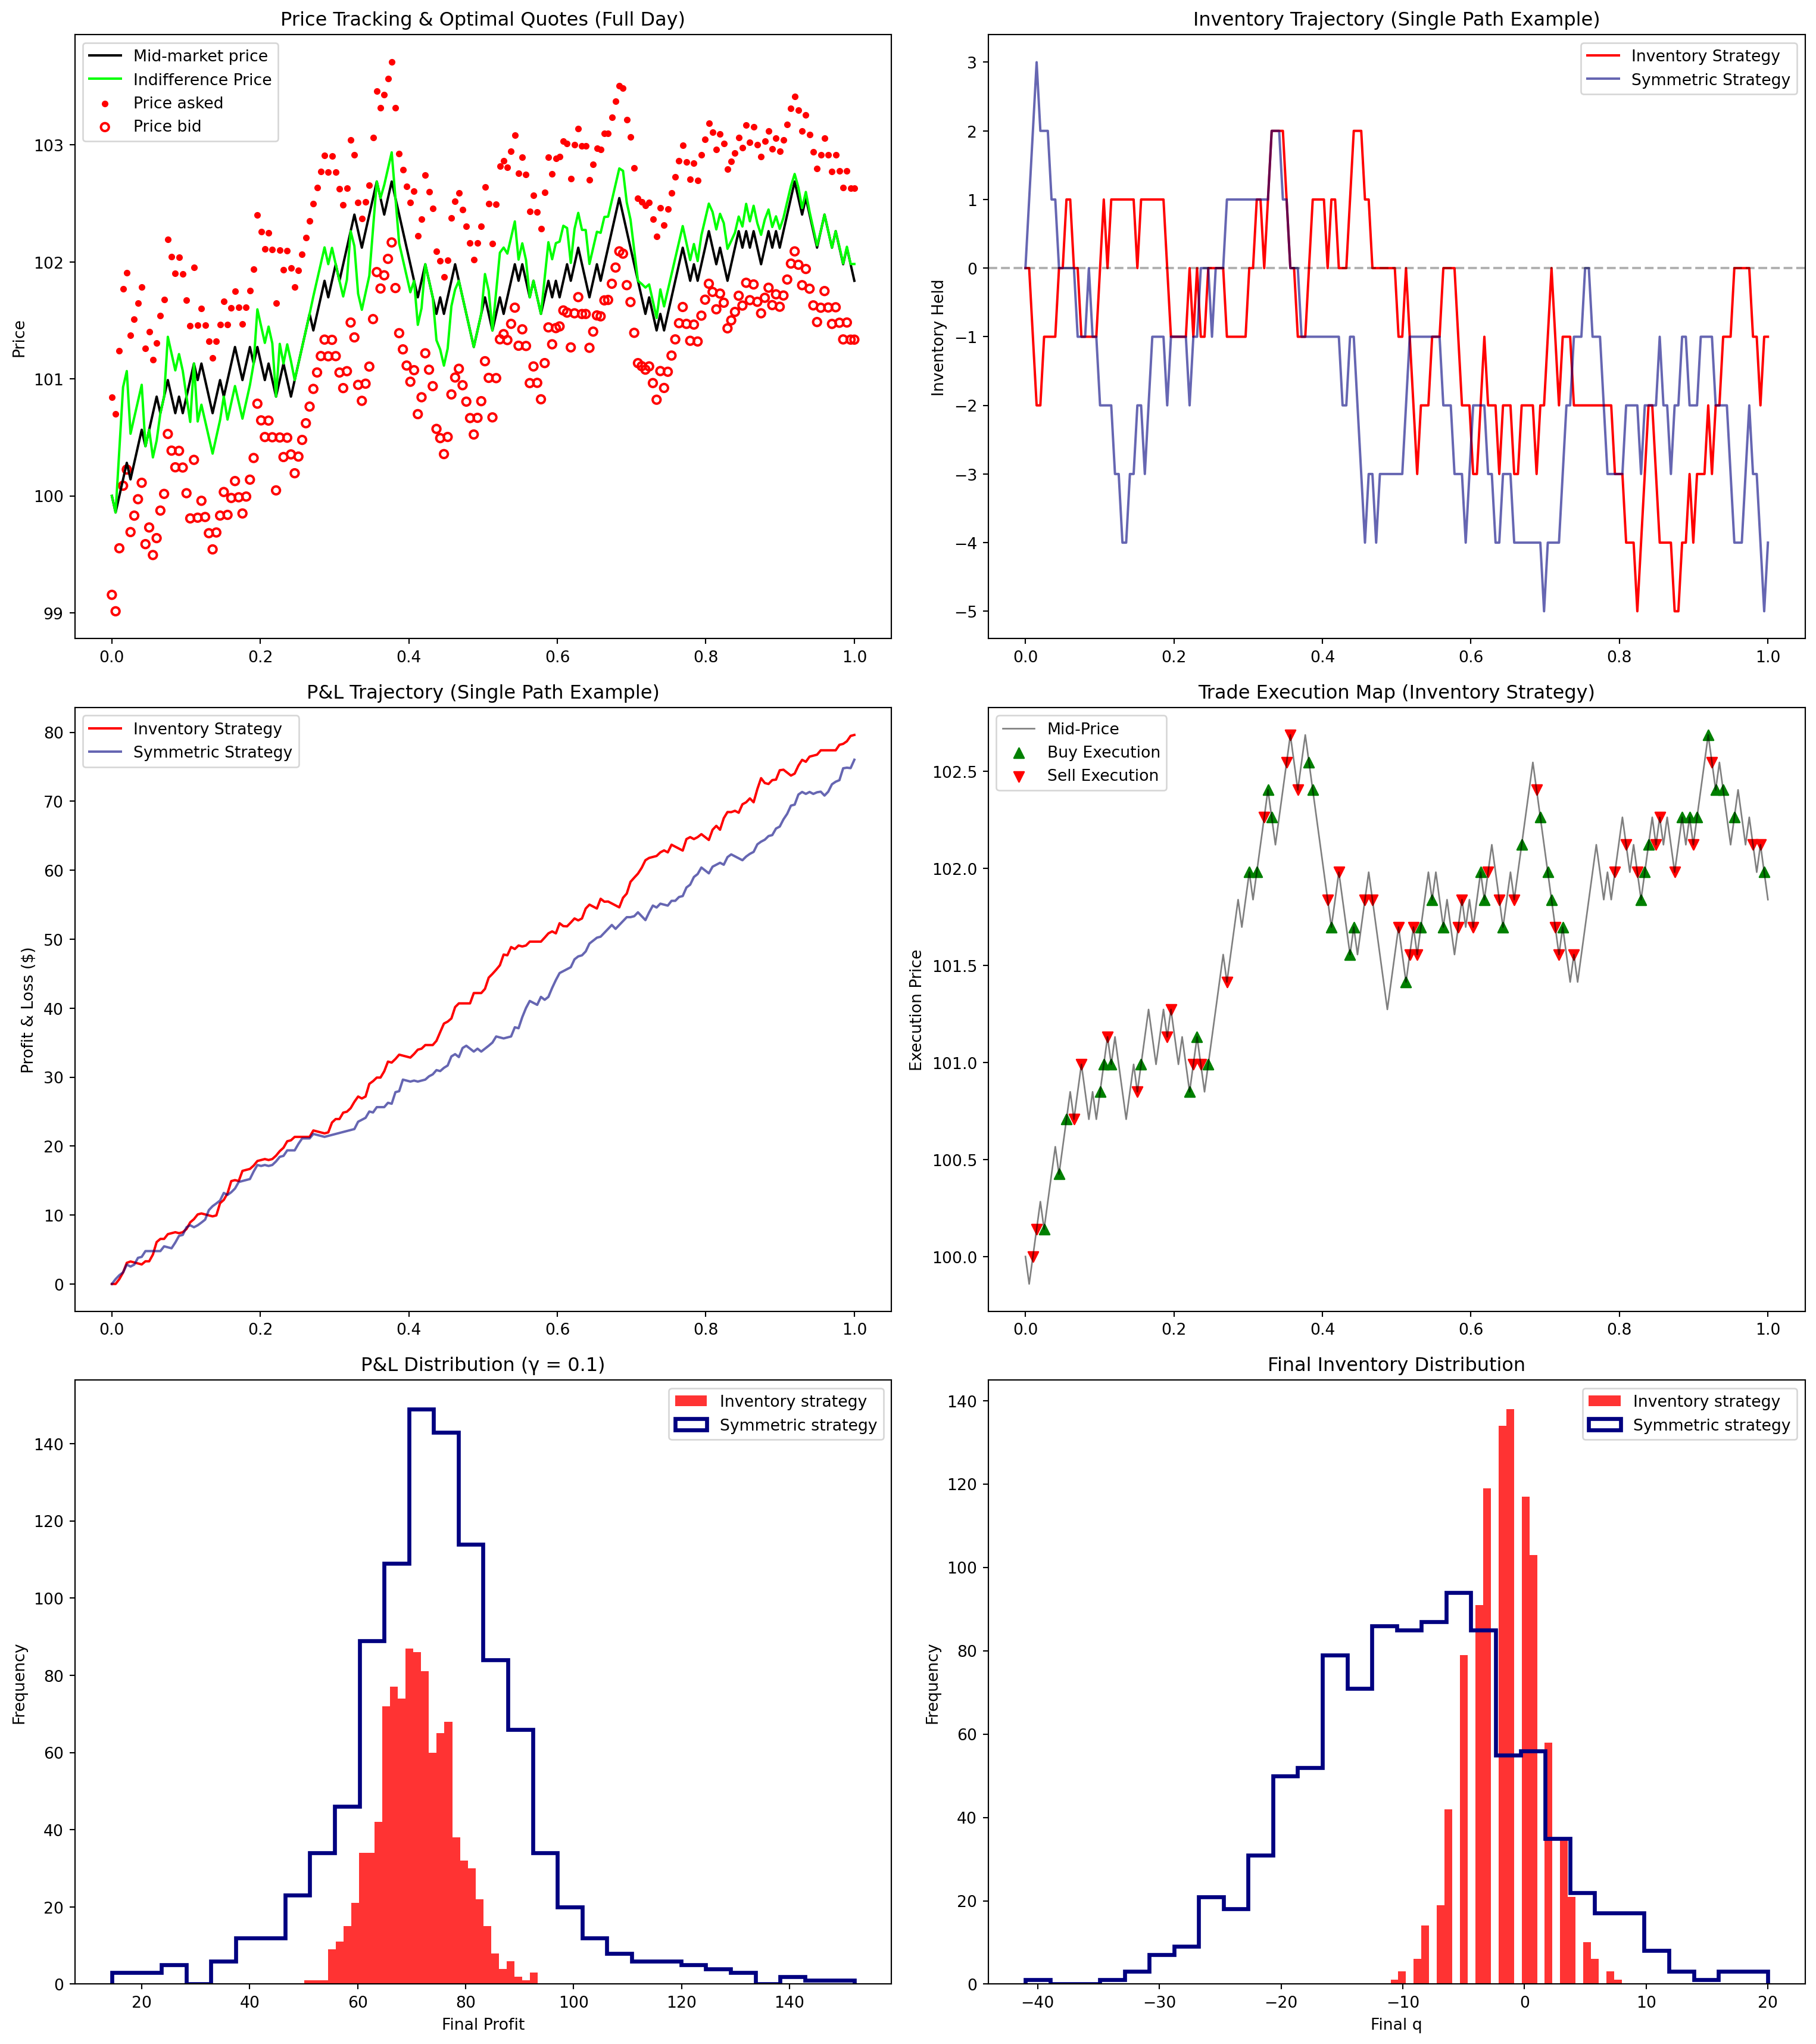

In [4]:
# ==========================================
# SCENARIO: TOXIC ORDER FLOW
# ==========================================
print("=== Running Toxic Order Flow Simulation ===")
print("Condition: Aggressive buyers arrive 20% faster than sellers (Market Trend)")

# We set ask_mult=1.2 to simulate heavy buying pressure
run_monte_carlo(ask_mult=1.2, bid_mult=1.0, jumps=False, gamma_val=0.1)

# Notice how the Symmetric strategy gets run over (huge negative inventory),
# while the Inventory strategy hikes its ask prices to defend its book.

## Part 4: Adding Jump-Diffusion (Fat Tails)

Standard Brownian motion ($dW_u$) creates continuous, smooth prices. Real financial markets experience "jumps" (fat tails)—sudden $2.00 price crashes or spikes between ticks.

=== Running Jump-Diffusion Simulation ===
Condition: Mid-price experiences sudden, random Poisson jumps (Fat Tails)
Running simulations, please wait...


--- Performance Metrics ---
 Strategy  Mean Profit  Std Dev (Profit)  Mean Final q  Std Dev (Final q)  Sharpe Ratio
Inventory        64.63              9.33         -0.15               2.93          6.93
Symmetric        66.69             32.13          0.04               8.54          2.08


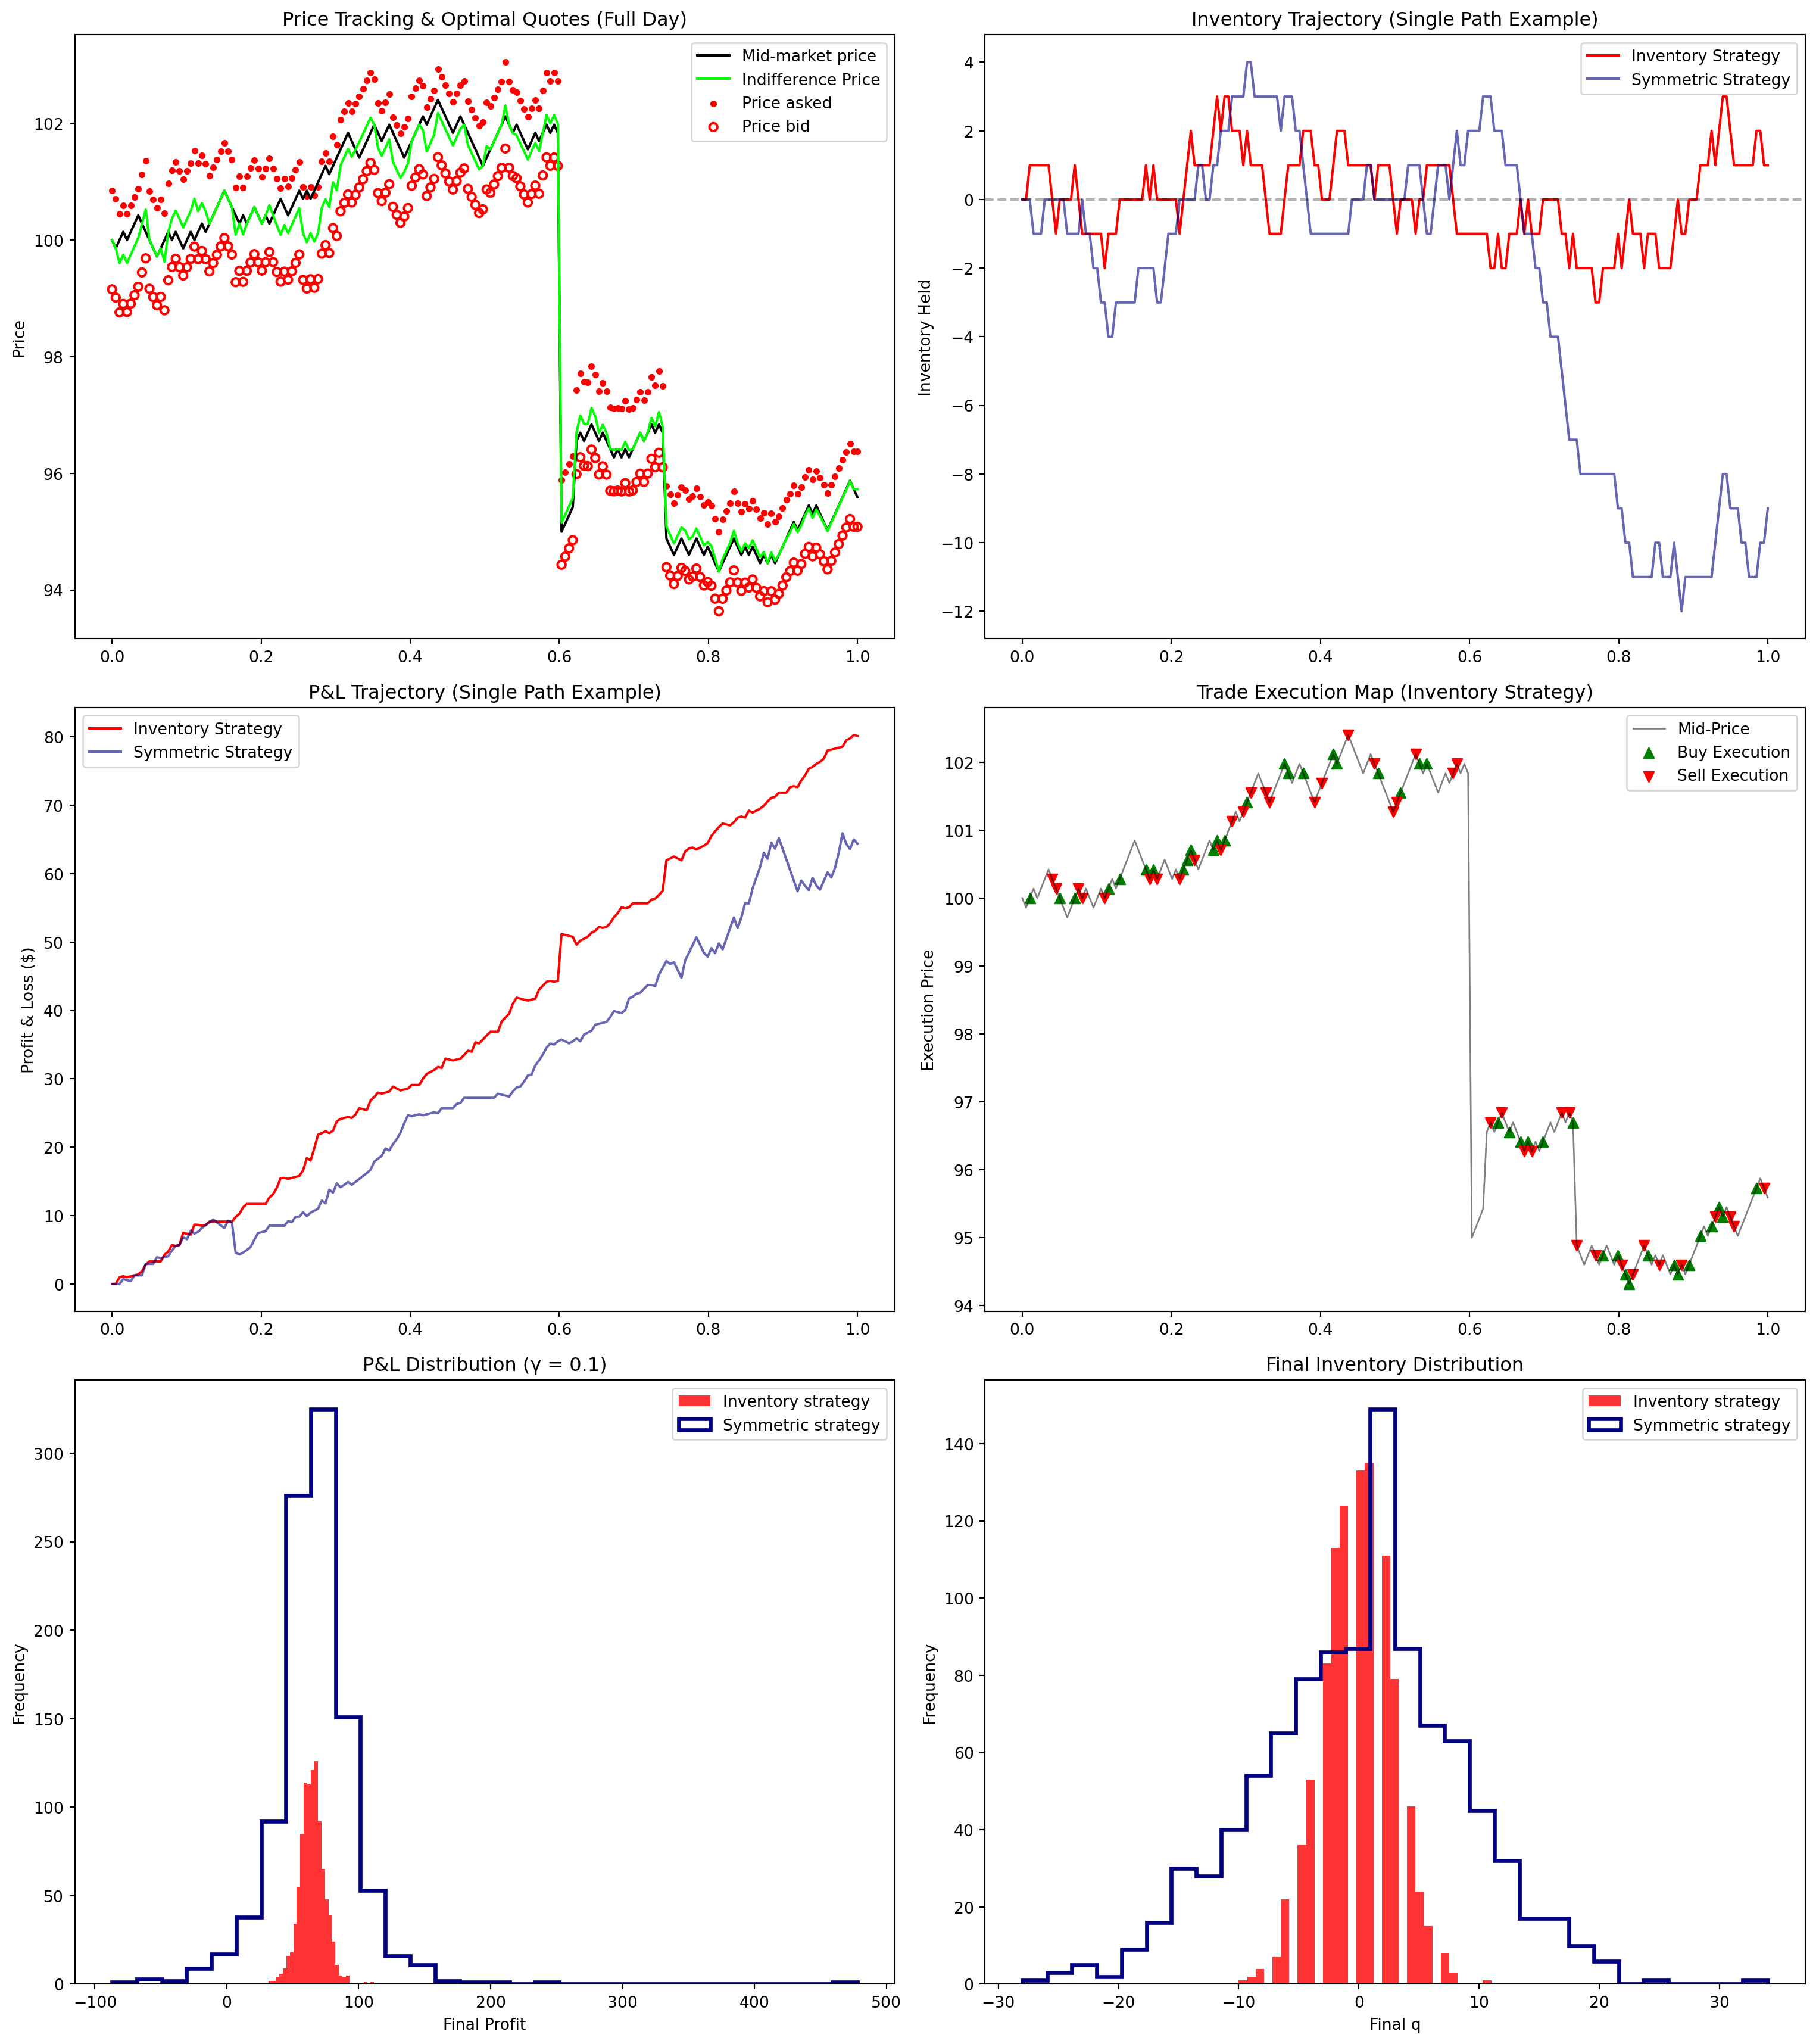

In [5]:
# ==========================================
# SCENARIO: FAT-TAIL JUMP DIFFUSION
# ==========================================
print("=== Running Jump-Diffusion Simulation ===")
print("Condition: Mid-price experiences sudden, random Poisson jumps (Fat Tails)")

# We set jumps=True to introduce market shocks
run_monte_carlo(ask_mult=1.0, bid_mult=1.0, jumps=True, gamma_val=0.1)

# Notice how the Symmetric strategy's P&L variance explodes because it is 
# often caught holding a large inventory right when a jump occurs.